# 05 — Ablation Study + Comparativa de Modelos

**Dataset:** Adult / Census Income (UCI id=2) — Clasificación binaria (`<=50K` vs `>50K`)

## Estructura del notebook

| Sección | Contenido |
|---|---|
| 1 | Carga de datos y pipelines |
| 2 | Definición de los 4 pasos del ablation |
| 3 | Ablation study — Keras (red neuronal) |
| 4 | Ablation study — PyTorch (red neuronal) |
| 5 | Ablation study — XGBoost |
| 6 | Comparativa entre modelos clásicos vs red neuronal final |
| 7 | Gráficos finales consolidados |
| 8 | Resumen tabular completo |

## Qué es el ablation study

Comparamos **4 configuraciones acumulativas**, midiendo la contribución real de cada componente:

```
Paso 1 — Sin FE, sin tuning   →  datos crudos + arquitectura mínima
Paso 2 — Con FE, sin tuning   →  datos con ingeniería de variables + arquitectura mínima  
Paso 3 — Con FE, con tuning   →  datos con FE + mejores hiperparámetros (Optuna)
Paso 4 — Modelo final         →  tuning + FE + entrenamiento sobre train completo
```

La diferencia de ROC-AUC entre pasos consecutivos cuantifica cuánto aportó cada componente.


## 1. Carga de datos y pipelines

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, json, copy, random, multiprocessing, joblib, warnings
warnings.filterwarnings('ignore')

# ── Deep Learning ───────────────────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

# ── Clásicos ────────────────────────────────────────────────────────────────
from xgboost import XGBClassifier
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier
from sklearn.svm           import SVC
from sklearn.pipeline      import Pipeline
from sklearn.preprocessing import (StandardScaler, OneHotEncoder,
                                   FunctionTransformer)
from sklearn.impute        import SimpleImputer
from sklearn.compose       import ColumnTransformer
from sklearn.base          import BaseEstimator, TransformerMixin
from sklearn.tree          import DecisionTreeClassifier
from sklearn.exceptions    import NotFittedError
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                             confusion_matrix, roc_curve,
                             precision_recall_curve, average_precision_score,
                             ConfusionMatrixDisplay)
from ucimlrepo import fetch_ucirepo

# ── Semilla global ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# ── CPU / GPU ───────────────────────────────────────────────────────────────
N_CPUS = max(1, multiprocessing.cpu_count() - 1)
DEVICE_TORCH = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch device : {DEVICE_TORCH}")

def _xgb_device():
    try:
        XGBClassifier(device='cuda', n_estimators=2, verbosity=0).fit(
            np.random.rand(16,3), [0,1]*8)
        return 'cuda'
    except Exception:
        return 'cpu'
XGB_DEVICE = _xgb_device()
print(f"XGBoost device : {XGB_DEVICE}")

os.makedirs("plots/ablation", exist_ok=True)
os.makedirs("modelo_final",   exist_ok=True)


In [ ]:
# ── Carga cruda ────────────────────────────────────────────────────────────
print("Cargando datos desde UCI...")
adult  = fetch_ucirepo(id=2)
df_raw = adult.data.original.copy()
df_raw.replace('?', np.nan, inplace=True)
df_raw['income'] = df_raw['income'].str.strip().replace(
    {'<=50K.': '<=50K', '>50K.': '>50K'})
df_raw['native-country'] = df_raw['native-country'].replace(
    {'South': 'South-Korea', 'Hong': 'Hong-Kong'})
df_raw.drop(columns=['fnlwgt'], inplace=True)

X_raw = df_raw.drop(columns=['income'])
y_raw = df_raw['income'].map({'<=50K': 0, '>50K': 1})

# Split global — MISMO para todos los modelos (reproducibilidad)
X_train_raw, X_test_raw, y_train_s, y_test_s = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=SEED, stratify=y_raw)
y_train_full = y_train_s.values
y_test       = y_test_s.values
print(f"Train: {X_train_raw.shape[0]} | Test: {X_test_raw.shape[0]}")
print(f"Balance test: {y_test.mean():.1%} positivos")


In [ ]:
# ── Feature Engineering (idéntico al notebook 02) ─────────────────────────
def regionalizar_paises(X):
    X_copy = X.copy()
    region_mapping = {
        'United-States':'EEUU','Canada':'Norteamerica_Otros',
        'Outlying-US(Guam-USVI-etc)':'Norteamerica_Otros',
        'Mexico':'Latinoamerica','Puerto-Rico':'Latinoamerica',
        'El-Salvador':'Latinoamerica','Cuba':'Latinoamerica',
        'Jamaica':'Latinoamerica','Dominican-Republic':'Latinoamerica',
        'Guatemala':'Latinoamerica','Columbia':'Latinoamerica',
        'Haiti':'Latinoamerica','Nicaragua':'Latinoamerica',
        'Peru':'Latinoamerica','Ecuador':'Latinoamerica',
        'Trinadad&Tobago':'Latinoamerica','Honduras':'Latinoamerica',
        'Argentina':'Latinoamerica','Chile':'Latinoamerica',
        'Brasil':'Latinoamerica','Venezuela':'Latinoamerica',
        'Germany':'Europa','England':'Europa','Italy':'Europa',
        'Poland':'Europa','Portugal':'Europa','Greece':'Europa',
        'France':'Europa','Ireland':'Europa','Yugoslavia':'Europa',
        'Scotland':'Europa','Hungary':'Europa','Holand-Netherlands':'Europa',
        'Philippines':'Asia','India':'Asia','China':'Asia','Japan':'Asia',
        'Vietnam':'Asia','Taiwan':'Asia','Iran':'Asia',
        'Hong Kong':'Asia','Hong-Kong':'Asia',
        'Thailand':'Asia','Cambodia':'Asia','Laos':'Asia','South-Korea':'Asia',
    }
    X_copy['region'] = X_copy['native-country'].map(region_mapping)
    return X_copy.drop('native-country', axis=1)

def agrupar_educacion(X):
    X_copy = X.copy()
    edu_map = {
        'Preschool':'Basica_Incompleta','1st-4th':'Basica_Incompleta',
        '5th-6th':'Basica_Incompleta','7th-8th':'Basica_Incompleta',
        '9th':'Basica_Incompleta','10th':'Basica_Incompleta',
        '11th':'Basica_Incompleta','12th':'Basica_Incompleta',
        'HS-grad':'Secundaria_Completa',
        'Some-college':'Tecnica_o_Universitaria_Incompleta',
        'Assoc-voc':'Tecnica_o_Universitaria_Incompleta',
        'Assoc-acdm':'Tecnica_o_Universitaria_Incompleta',
        'Bachelors':'Universitaria','Masters':'Maestría',
        'Prof-school':'Escuela_profesional','Doctorate':'Doctorado',
    }
    X_copy['nivel_educativo'] = X_copy['education'].map(edu_map)
    return X_copy.drop(
        [c for c in ['education','education-num'] if c in X_copy.columns], axis=1)

def agrupar_ocupacion(X):
    X_copy = X.copy()
    occ_map = {
        'Exec-managerial':'Administrativo_Especializado',
        'Prof-specialty':'Administrativo_Especializado',
        'Tech-support':'Administrativo_Especializado',
        'Adm-clerical':'Administrativo_Especializado',
        'Sales':'Administrativo_Especializado',
        'Craft-repair':'Operativo_Manual',
        'Machine-op-inspct':'Operativo_Manual',
        'Transport-moving':'Operativo_Manual',
        'Handlers-cleaners':'Operativo_Manual',
        'Farming-fishing':'Operativo_Manual',
        'Protective-serv':'Servicios','Other-service':'Servicios',
        'Priv-house-serv':'Servicios','Armed-Forces':'Otros_Militar',
    }
    X_copy['perfil_ocupacional'] = X_copy['occupation'].map(occ_map)
    return X_copy.drop('occupation', axis=1)

def log1p_capital(X):
    X_copy = X.copy()
    X_copy['log_capital_gain'] = np.log1p(X_copy['capital-gain'])
    X_copy['log_capital_loss'] = np.log1p(X_copy['capital-loss'])
    return X_copy.drop(columns=['capital-gain','capital-loss'])

def imputar_desconocido(X):
    X_copy = X.copy()
    for col in ['workclass','region','perfil_ocupacional']:
        if col in X_copy.columns:
            X_copy[col] = X_copy[col].fillna('Desconocido')
    return X_copy

class DiscretizadorSupervisado(BaseEstimator, TransformerMixin):
    def __init__(self, max_depth=3, random_state=42):
        self.max_depth=max_depth; self.random_state=random_state
    def fit(self, X, y=None):
        if y is None: raise ValueError("Requiere y")
        if not isinstance(X, pd.DataFrame): X = pd.DataFrame(X)
        self.arboles_ = []
        for col in X.columns:
            arbol = DecisionTreeClassifier(
                max_depth=self.max_depth, random_state=self.random_state)
            arbol.fit(X[[col]], y); self.arboles_.append(arbol)
        return self
    def transform(self, X, y=None):
        if not hasattr(self,'arboles_'): raise NotFittedError("No fiteado")
        if not isinstance(X, pd.DataFrame): X = pd.DataFrame(X)
        X_copy = X.copy()
        for i, col in enumerate(X.columns):
            X_copy[col] = self.arboles_[i].predict_proba(X[[col]])[:,1]
        return X_copy.to_numpy()

class DiscretizadorCapital(BaseEstimator, TransformerMixin):
    def __init__(self, max_depth=3, random_state=42):
        self.max_depth=max_depth; self.random_state=random_state
    def fit(self, X, y=None):
        self._disc = DiscretizadorSupervisado(self.max_depth, self.random_state)
        self._disc.fit(X[['capital-gain','capital-loss']], y)
        proba = self._disc.transform(X[['capital-gain','capital-loss']])
        proba_df = pd.DataFrame(proba, columns=['capital-gain','capital-loss'])
        self.mapeos_ = {
            col:{v:f"Nivel_{i+1}" for i,v in enumerate(sorted(proba_df[col].unique()))}
            for col in ['capital-gain','capital-loss']}
        return self
    def transform(self, X, y=None):
        X_copy = X.copy().reset_index(drop=True)
        proba = self._disc.transform(X_copy[['capital-gain','capital-loss']])
        proba_df = pd.DataFrame(proba, columns=['capital-gain','capital-loss'])
        X_copy['cat_capital-gain'] = proba_df['capital-gain'].map(self.mapeos_['capital-gain'])
        X_copy['cat_capital-loss'] = proba_df['capital-loss'].map(self.mapeos_['capital-loss'])
        return X_copy.drop(columns=['capital-gain','capital-loss'])


## 2. Los cuatro datasets del ablation

In [ ]:
# ══════════════════════════════════════════════════════════
# Los 4 datasets corresponden a los 4 pasos del ablation:
#   A — Sin FE  (pipeline mínimo: OHE + Scaler sobre datos crudos)
#   B — Con FE  (pipeline_log completo, igual que en 03_modelo_keras.py)
#   Los pasos 3 y 4 reusan dataset B, cambiando solo hiperparámetros/datos
# ══════════════════════════════════════════════════════════

# ── Pipeline SIN FE (paso 1 del ablation) ──────────────────
# Solo OHE + StandardScaler sobre columnas crudas. Sin agrupamientos,
# sin log1p, sin discretización. Es el baseline "datos en bruto".
_num_raw = ['age','education-num','hours-per-week','capital-gain','capital-loss']
_cat_raw = ['workclass','education','marital-status','occupation',
            'relationship','race','sex','native-country']

pipeline_sin_fe = Pipeline([
    ('prep', ColumnTransformer([
        ('num', Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('sc',  StandardScaler()),
        ]), _num_raw),
        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='constant', fill_value='Desconocido')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), _cat_raw),
    ], remainder='drop')),
])

# ── Pipeline CON FE = pipeline_log (paso 2,3,4 del ablation) ─
_cat_base = ['workclass','marital-status','relationship','race','sex',
             'region','nivel_educativo','perfil_ocupacional']
_col_log  = {'num': ['age','hours-per-week','log_capital_gain','log_capital_loss'],
             'cat': _cat_base}

def _build_ct(cols):
    return ColumnTransformer([
        ('num', StandardScaler(), cols['num']),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols['cat']),
    ], remainder='drop')

_pasos_comunes = [
    ('regionalizar',        FunctionTransformer(regionalizar_paises)),
    ('agrupar_educacion',   FunctionTransformer(agrupar_educacion)),
    ('agrupar_ocupacion',   FunctionTransformer(agrupar_ocupacion)),
    ('imputar_desconocido', FunctionTransformer(imputar_desconocido)),
]

pipeline_con_fe = Pipeline(_pasos_comunes + [
    ('log1p_capital',    FunctionTransformer(log1p_capital)),
    ('encoding_scaling', _build_ct(_col_log)),
])

# ── Fit y transform ────────────────────────────────────────
print("Construyendo datasets A (sin FE) y B (con FE)...")
X_A_train = pipeline_sin_fe.fit_transform(X_train_raw)
X_A_test  = pipeline_sin_fe.transform(X_test_raw)

X_B_train = pipeline_con_fe.fit_transform(X_train_raw, y_train_s)
X_B_test  = pipeline_con_fe.transform(X_test_raw)

print(f"  A — sin FE : train {X_A_train.shape} | test {X_A_test.shape}")
print(f"  B — con FE : train {X_B_train.shape} | test {X_B_test.shape}")

# Split 85/15 para validación dentro del ablation
X_A_tr, X_A_val, y_tr, y_val = train_test_split(
    X_A_train, y_train_full, test_size=0.15, random_state=SEED, stratify=y_train_full)
X_B_tr, X_B_val, _,    _    = train_test_split(
    X_B_train, y_train_full, test_size=0.15, random_state=SEED, stratify=y_train_full)

# Class weights
pesos = compute_class_weight('balanced', classes=np.array([0,1]), y=y_tr)
CW    = dict(zip([0,1], pesos))
print(f"  class_weight: {CW}")


In [ ]:
# ── Helper de evaluación universal ─────────────────────────────────────────
def evaluar(model_fn, X, y, nombre):
    """Acepta cualquier callable que devuelva probabilidades P(y=1)."""
    prob = model_fn(X)
    pred = (prob >= 0.5).astype(int)
    return {
        'nombre': nombre,
        'auc':    roc_auc_score(y, prob),
        'pr_auc': average_precision_score(y, prob),
        'f1':     f1_score(y, pred),
        'acc':    accuracy_score(y, pred),
        'prob':   prob,
        'pred':   pred,
        'cm':     confusion_matrix(y, pred),
    }

def _print_res(res):
    print(f"  {res['nombre']:<35} "
          f"AUC={res['auc']:.4f}  PR-AUC={res['pr_auc']:.4f}  "
          f"F1={res['f1']:.4f}  Acc={res['acc']:.4f}")


## 3. Ablation Study — Keras

In [ ]:
import json as _json

# Leer hiperparámetros del modelo tuneado y final
with open("modelo_final/metricas_keras.json") as f:
    _mk = _json.load(f)

_kp = _mk["modelo_tuneado"]["params"]  # mejores hiperparámetros Optuna

def _keras_base(input_dim):
    """Arquitectura mínima (igual que build_base_model en 03_modelo_keras.py)"""
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='sigmoid'),
        layers.Dense(32, activation='sigmoid'),
        layers.Dense(1,  activation='sigmoid'),
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=[keras.metrics.AUC(name='auc')])
    return model

def _keras_tuned(input_dim, params):
    """Arquitectura tuneada (igual que build_tuned_model en 03_modelo_keras.py)"""
    capas   = params.get('capas',   [128])
    dropout = params.get('dropout', 0.3)
    l2      = params.get('l2',      1e-4)
    lr      = params.get('lr',      1e-3)
    inp = keras.Input(shape=(input_dim,))
    x   = inp
    for n in capas:
        x = layers.Dense(n, activation='relu',
                         kernel_regularizer=regularizers.l2(l2))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss='binary_crossentropy',
                  metrics=[keras.metrics.AUC(name='auc')])
    return model

_es = EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True,
                    mode='max', verbose=0)

print("─"*65)
print("Ablation Keras — entrenando 4 pasos...")

# PASO 1 — sin FE, arquitectura base
print("  [1/4] Sin FE + base...")
m1 = _keras_base(X_A_train.shape[1])
m1.fit(X_A_tr, y_tr, validation_data=(X_A_val, y_val),
       epochs=100, batch_size=256, class_weight=CW, callbacks=[_es], verbose=0)
res_k1 = evaluar(lambda X: m1.predict(X, verbose=0).ravel(), X_A_test, y_test,
                 "Keras — Sin FE, sin tuning")

# PASO 2 — con FE, arquitectura base (misma arquitectura, distintos datos)
print("  [2/4] Con FE + base...")
m2 = _keras_base(X_B_train.shape[1])
m2.fit(X_B_tr, y_tr, validation_data=(X_B_val, y_val),
       epochs=100, batch_size=256, class_weight=CW, callbacks=[_es], verbose=0)
res_k2 = evaluar(lambda X: m2.predict(X, verbose=0).ravel(), X_B_test, y_test,
                 "Keras — Con FE, sin tuning")

# PASO 3 — con FE + tuning (hiperparámetros Optuna del modelo 03)
print("  [3/4] Con FE + tuning...")
m3 = _keras_tuned(X_B_train.shape[1], _kp)
m3.fit(X_B_tr, y_tr, validation_data=(X_B_val, y_val),
       epochs=100, batch_size=_kp.get('batch', 256),
       class_weight=CW, callbacks=[_es], verbose=0)
res_k3 = evaluar(lambda X: m3.predict(X, verbose=0).ravel(), X_B_test, y_test,
                 "Keras — Con FE, con tuning")

# PASO 4 — modelo final (cargado directamente)
print("  [4/4] Modelo final (cargado)...")
modelo_keras_final = keras.models.load_model("modelo_final/modelo_keras_final.keras")
res_k4 = evaluar(lambda X: modelo_keras_final.predict(X, verbose=0).ravel(),
                 X_B_test, y_test, "Keras — Modelo final")

ablation_keras = [res_k1, res_k2, res_k3, res_k4]
print("\nResultados Keras:")
for r in ablation_keras: _print_res(r)


## 4. Ablation Study — PyTorch

In [ ]:
def _to_tensor(X):
    return torch.tensor(np.asarray(X), dtype=torch.float32, device=DEVICE_TORCH)

def _pt_predict(model, X):
    model.eval()
    with torch.no_grad():
        return torch.sigmoid(model(_to_tensor(X))).cpu().numpy().ravel()

def _pt_base(input_dim):
    return nn.Sequential(
        nn.Linear(input_dim,64), nn.ReLU(),
        nn.Linear(64,32),        nn.ReLU(),
        nn.Linear(32,1),
    ).to(DEVICE_TORCH)

def _pt_tuned(capas, dropout, input_dim):
    layers_list, prev = [], input_dim
    for n in capas:
        layers_list += [nn.Linear(prev,n), nn.ReLU(),
                        nn.BatchNorm1d(n), nn.Dropout(dropout)]
        prev = n
    layers_list += [nn.Linear(prev,1)]
    return nn.Sequential(*layers_list).to(DEVICE_TORCH)

def _pt_fit(model, X_tr, y_tr, X_va, y_va, lr=1e-3, l2=0.0,
            batch=256, epochs=100, patience=10):
    Xtr = _to_tensor(X_tr); ytr = torch.tensor(y_tr, dtype=torch.float32,
                                                device=DEVICE_TORCH).view(-1,1)
    Xva = _to_tensor(X_va); yva = torch.tensor(y_va, dtype=torch.float32,
                                                device=DEVICE_TORCH).view(-1,1)
    w_arr = np.where(y_tr==1, CW[1], CW[0])
    w_tr  = torch.tensor(w_arr, dtype=torch.float32, device=DEVICE_TORCH).view(-1,1)
    crit = nn.BCEWithLogitsLoss(reduction='none')
    opt  = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2)
    gen  = torch.Generator('cpu'); gen.manual_seed(SEED)
    ds   = TensorDataset(Xtr, ytr, w_tr)
    dl   = DataLoader(ds, batch_size=batch, shuffle=True, generator=gen)
    best_auc, best_state, sin_mejora = -np.inf, None, 0
    for ep in range(epochs):
        model.train()
        for xb, yb, wb in dl:
            opt.zero_grad()
            (crit(model(xb), yb)*wb).mean().backward(); opt.step()
        prob_va = _pt_predict(model, X_va)
        auc_va  = roc_auc_score(y_va, prob_va)
        if auc_va > best_auc:
            best_auc, best_state, sin_mejora = auc_va, copy.deepcopy(model.state_dict()), 0
        else:
            sin_mejora += 1
            if sin_mejora >= patience: break
    if best_state: model.load_state_dict(best_state)

with open("modelo_final/metricas_pytorch.json") as f:
    _mp = _json.load(f)
_pp = _mp["modelo_tuneado"]["params"]  # hiperparámetros Optuna

print("─"*65)
print("Ablation PyTorch — entrenando 4 pasos...")

# PASO 1 — sin FE, base
print("  [1/4] Sin FE + base...")
m1p = _pt_base(X_A_train.shape[1])
_pt_fit(m1p, X_A_tr, y_tr, X_A_val, y_val)
res_p1 = evaluar(lambda X: _pt_predict(m1p, X), X_A_test, y_test,
                 "PyTorch — Sin FE, sin tuning")

# PASO 2 — con FE, base
print("  [2/4] Con FE + base...")
m2p = _pt_base(X_B_train.shape[1])
_pt_fit(m2p, X_B_tr, y_tr, X_B_val, y_val)
res_p2 = evaluar(lambda X: _pt_predict(m2p, X), X_B_test, y_test,
                 "PyTorch — Con FE, sin tuning")

# PASO 3 — con FE + tuning
print("  [3/4] Con FE + tuning...")
m3p = _pt_tuned(_pp['capas'], _pp['dropout'], X_B_train.shape[1])
_pt_fit(m3p, X_B_tr, y_tr, X_B_val, y_val,
        lr=_pp['lr'], l2=_pp['l2'], batch=_pp['batch'])
res_p3 = evaluar(lambda X: _pt_predict(m3p, X), X_B_test, y_test,
                 "PyTorch — Con FE, con tuning")

# PASO 4 — modelo final (cargado)
print("  [4/4] Modelo final (cargado)...")
arch_pt = joblib.load("modelo_final/arquitectura_pytorch.pkl")
m4p = _pt_tuned(**arch_pt)
m4p.load_state_dict(torch.load("modelo_final/modelo_pytorch_final.pt",
                                map_location='cpu'))
res_p4 = evaluar(lambda X: _pt_predict(m4p, X), X_B_test, y_test,
                 "PyTorch — Modelo final")

ablation_pytorch = [res_p1, res_p2, res_p3, res_p4]
print("\nResultados PyTorch:")
for r in ablation_pytorch: _print_res(r)


## 5. Ablation Study — XGBoost

In [9]:
# ── CastCategorias redefinida aquí para que joblib.load la encuentre ─────────
# joblib necesita que la clase esté en el namespace en el momento de
# deserializar el .pkl, independientemente de que esté definida en otra celda.
class CastCategorias:
    """Fija las categorías aprendidas en train para columnas categóricas."""
    def __init__(self, cat_cols): self.cat_cols = cat_cols
    def fit(self, X, y=None):
        self.categorias_ = {c: pd.unique(X[c].dropna()) for c in self.cat_cols}
        return self
    def transform(self, X):
        X = X.copy()
        for c in self.cat_cols:
            X[c] = pd.Categorical(X[c], categories=self.categorias_[c])
        return X

# XGBoost tiene su propio pipeline lean (07_modelo_xgboost.ipynb)
# El "sin FE" usa datos crudos con OHE; el "con FE" usa el pipeline lean

# Recuperar hiperparámetros Optuna y preprocesador
with open("modelo_final/metricas_xgboost.json") as f:
    _mxgb = _json.load(f)
_xp = _mxgb["modelo_tuneado"]["params"]
_xp_clean = {k:v for k,v in _xp.items()
             if k not in ('optuna_trial','optuna_val_auc','pipeline_principal')}

_prep_xgb = joblib.load("modelo_final/preprocesador_xgboost.pkl")
cast    = _prep_xgb["cast"]
ohe_ct  = _prep_xgb["ohe_ct"]
NUM_COLS = _prep_xgb["num_cols"]
CAT_COLS = _prep_xgb["cat_cols"]

# Datos sin FE — reutilizamos X_A (OHE crudo, sin escalar para XGBoost)
_ct_sinfe = ColumnTransformer([
    ('num', 'passthrough', ['age','education-num','hours-per-week',
                            'capital-gain','capital-loss']),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='constant', fill_value='Desconocido')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]), ['workclass','education','marital-status','occupation',
         'relationship','race','sex','native-country']),
], remainder='drop')
Xxgb_A_train = _ct_sinfe.fit_transform(X_train_raw)
Xxgb_A_test  = _ct_sinfe.transform(X_test_raw)

# Datos con FE (pipeline lean nativo — idéntico al 07_modelo_xgboost.ipynb)
def preparar_base_xgb(df):
    X = df.copy()
    X = regionalizar_paises(X)
    if 'education' in X.columns: X = X.drop(columns=['education'])
    for c in NUM_COLS:
        X[c] = pd.to_numeric(X[c], errors='coerce')
    for c in CAT_COLS:
        X[c] = X[c].astype('object')
    return X[NUM_COLS + CAT_COLS]

Xxgb_B_train_raw = preparar_base_xgb(X_train_raw)
Xxgb_B_test_raw  = preparar_base_xgb(X_test_raw)
Xxgb_B_train = cast.transform(Xxgb_B_train_raw)  # dtype category
Xxgb_B_test  = cast.transform(Xxgb_B_test_raw)

Xxgb_A_tr, Xxgb_A_val, _, _ = train_test_split(
    Xxgb_A_train, y_train_full, test_size=0.15, random_state=SEED, stratify=y_train_full)
Xxgb_B_tr, Xxgb_B_val, _, _ = train_test_split(
    Xxgb_B_train, y_train_full, test_size=0.15, random_state=SEED, stratify=y_train_full)

SCALE_PW = float((y_tr==0).sum()/(y_tr==1).sum())

def _xgb_base(cat=False):
    return XGBClassifier(
        n_estimators=600, max_depth=6, learning_rate=0.1,
        subsample=0.9, colsample_bytree=0.9,
        objective='binary:logistic', eval_metric=['logloss','auc'],
        early_stopping_rounds=50, scale_pos_weight=SCALE_PW,
        tree_method='hist', device=XGB_DEVICE, enable_categorical=cat,
        n_jobs=N_CPUS, random_state=SEED, verbosity=0)

def _xgb_tuned(params, cat=False):
    return XGBClassifier(
        objective='binary:logistic', eval_metric=['logloss','auc'],
        early_stopping_rounds=50, scale_pos_weight=SCALE_PW,
        tree_method='hist', device=XGB_DEVICE, enable_categorical=cat,
        n_jobs=N_CPUS, random_state=SEED, verbosity=0, **params)

def _xgb_fit(m, Xtr, ytr, Xva, yva):
    m.fit(Xtr, ytr, eval_set=[(Xtr,ytr),(Xva,yva)], verbose=False)

print("─"*65)
print("Ablation XGBoost — entrenando 4 pasos...")

# PASO 1 — sin FE, base
print("  [1/4] Sin FE + base...")
m1x = _xgb_base(cat=False)
_xgb_fit(m1x, Xxgb_A_tr, y_tr, Xxgb_A_val, y_val)
res_x1 = evaluar(lambda X: m1x.predict_proba(X)[:,1], Xxgb_A_test, y_test,
                 "XGBoost — Sin FE, sin tuning")

# PASO 2 — con FE, base (nativo)
print("  [2/4] Con FE + base...")
m2x = _xgb_base(cat=True)
_xgb_fit(m2x, Xxgb_B_tr, y_tr, Xxgb_B_val, y_val)
res_x2 = evaluar(lambda X: m2x.predict_proba(X)[:,1], Xxgb_B_test, y_test,
                 "XGBoost — Con FE, sin tuning")

# PASO 3 — con FE + tuning
print("  [3/4] Con FE + tuning...")
m3x = _xgb_tuned(_xp_clean, cat=True)
_xgb_fit(m3x, Xxgb_B_tr, y_tr, Xxgb_B_val, y_val)
res_x3 = evaluar(lambda X: m3x.predict_proba(X)[:,1], Xxgb_B_test, y_test,
                 "XGBoost — Con FE, con tuning")

# PASO 4 — modelo final (cargado)
print("  [4/4] Modelo final (cargado)...")
m4x = XGBClassifier(enable_categorical=True)
m4x.load_model("modelo_final/modelo_xgboost_final.json")
res_x4 = evaluar(lambda X: m4x.predict_proba(X)[:,1], Xxgb_B_test, y_test,
                 "XGBoost — Modelo final")

ablation_xgboost = [res_x1, res_x2, res_x3, res_x4]
print("\nResultados XGBoost:")
for r in ablation_xgboost: _print_res(r)


─────────────────────────────────────────────────────────────────
Ablation XGBoost — entrenando 4 pasos...
  [1/4] Sin FE + base...
  [2/4] Con FE + base...
  [3/4] Con FE + tuning...
  [4/4] Modelo final (cargado)...

Resultados XGBoost:
  XGBoost — Sin FE, sin tuning        AUC=0.9315  PR-AUC=0.8355  F1=0.7120  Acc=0.8332
  XGBoost — Con FE, sin tuning        AUC=0.9315  PR-AUC=0.8361  F1=0.7116  Acc=0.8336
  XGBoost — Con FE, con tuning        AUC=0.9322  PR-AUC=0.8377  F1=0.7157  Acc=0.8368
  XGBoost — Modelo final              AUC=0.9323  PR-AUC=0.8388  F1=0.7163  Acc=0.8378


## 6. Gráficos del Ablation Study

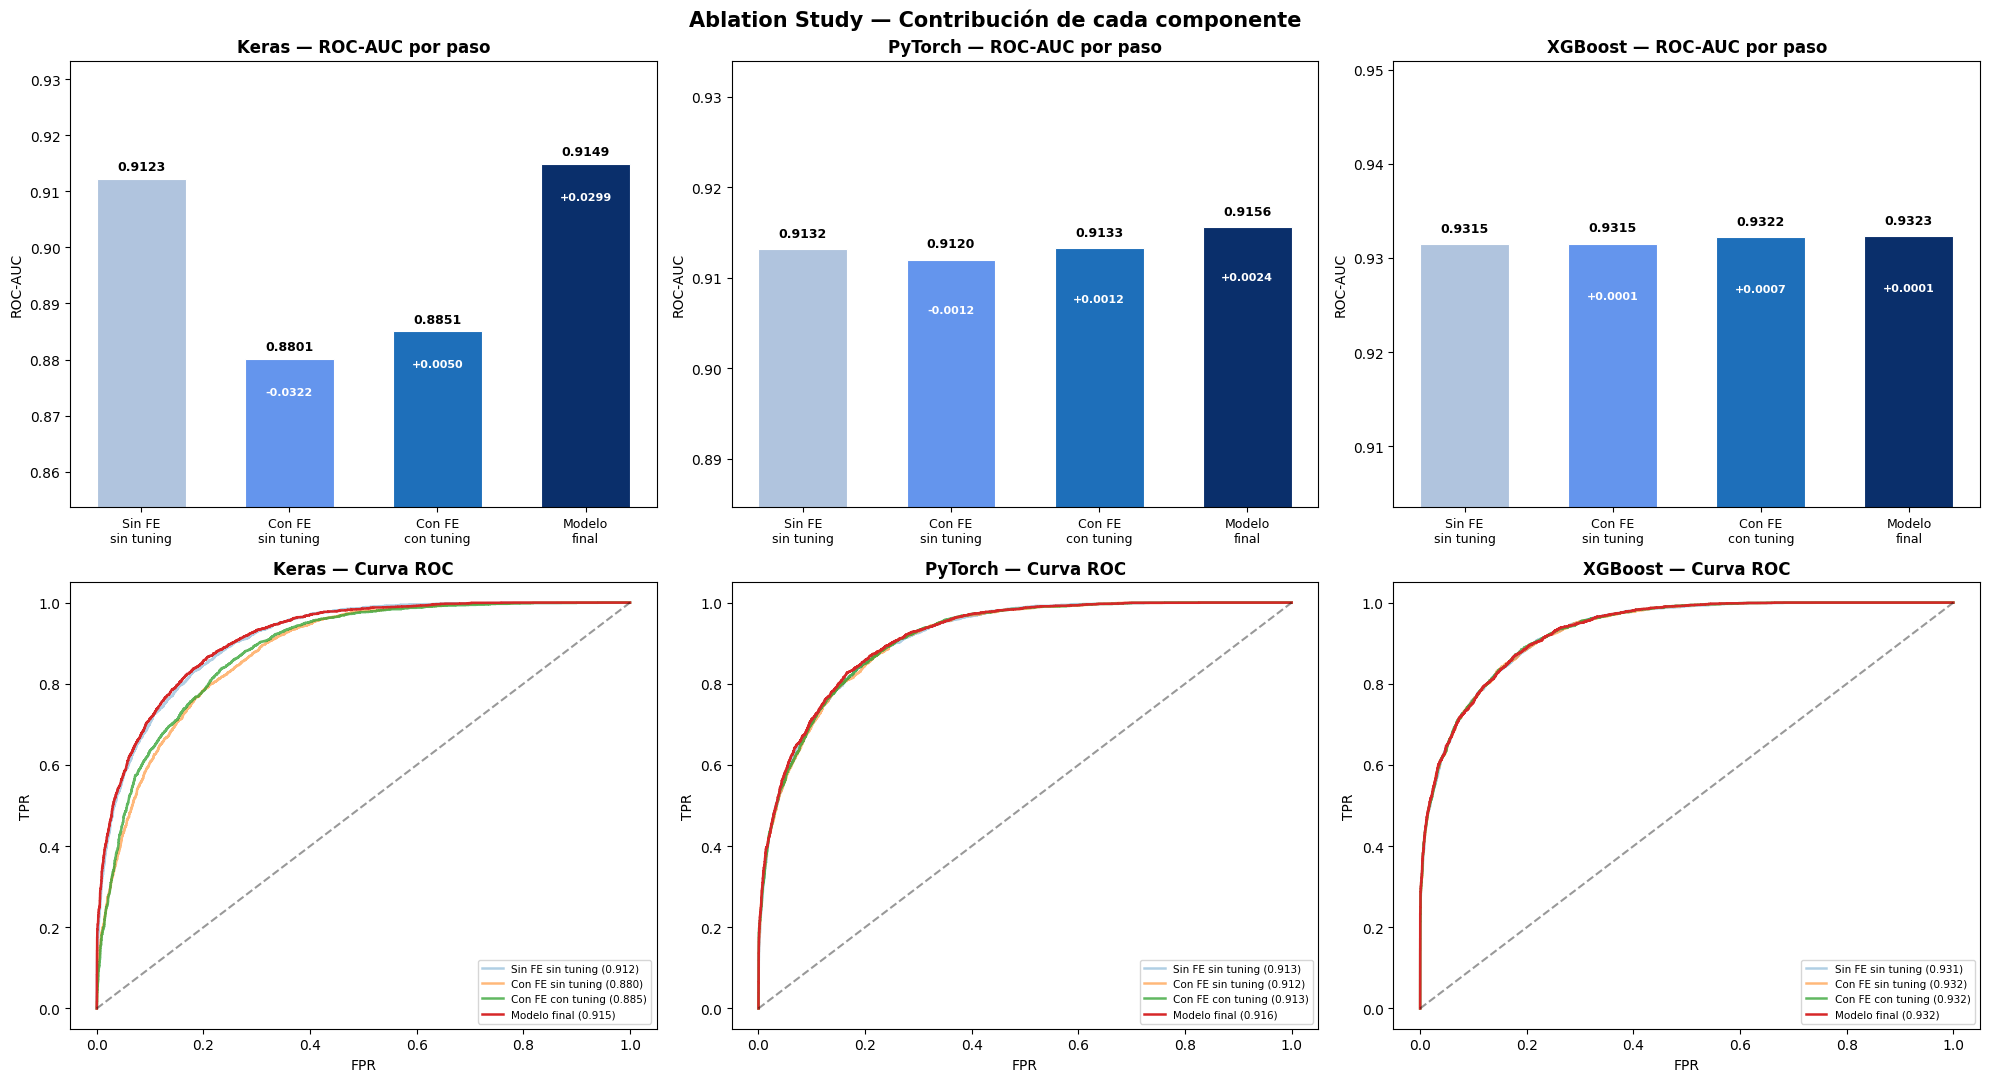

✅ Gráfico ablation guardado en plots/ablation/ablation_waterfall_roc.png


In [10]:
pasos_lbl = ["Sin FE\nsin tuning", "Con FE\nsin tuning",
             "Con FE\ncon tuning", "Modelo\nfinal"]
colores   = ["#b0c4de","#6495ed","#1e6fba","#0a2f6b"]

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle("Ablation Study — Contribución de cada componente", fontsize=15, fontweight='bold')

for col_idx, (ablation, nombre, color_base) in enumerate([
    (ablation_keras,   "Keras",   "#1e6fba"),
    (ablation_pytorch, "PyTorch", "#1b6e44"),
    (ablation_xgboost, "XGBoost", "#8b2500"),
]):
    aucs = [r['auc'] for r in ablation]

    # — Fila 0: barras de AUC (waterfall) —
    ax = axes[0, col_idx]
    bars = ax.bar(pasos_lbl, aucs, color=colores[:len(aucs)], edgecolor='white',
                  linewidth=0.8, width=0.6)
    ax.set_ylim(min(aucs)*0.97, min(max(aucs)*1.02, 1.0))
    ax.set_title(f"{nombre} — ROC-AUC por paso", fontweight='bold')
    ax.set_ylabel("ROC-AUC")
    ax.tick_params(axis='x', labelsize=9)
    for bar, val, prev in zip(bars, aucs, [None]+aucs):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                f"{val:.4f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
        if prev is not None:
            delta = val - prev
            sign  = "+" if delta >= 0 else ""
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()-0.005,
                    f"{sign}{delta:.4f}", ha='center', va='top',
                    fontsize=8, color='white', fontweight='bold')

    # — Fila 1: curvas ROC de los 4 pasos —
    ax = axes[1, col_idx]
    alphas = [0.35, 0.55, 0.75, 1.0]
    for res, lbl, alpha in zip(ablation, pasos_lbl, alphas):
        fpr, tpr, _ = roc_curve(y_test, res['prob'])
        ax.plot(fpr, tpr, label=f"{lbl.replace(chr(10),' ')} ({res['auc']:.3f})",
                alpha=alpha, linewidth=1.8)
    ax.plot([0,1],[0,1],'k--',alpha=0.4)
    ax.set_title(f"{nombre} — Curva ROC", fontweight='bold')
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.legend(fontsize=7.5)

plt.tight_layout()
plt.savefig("plots/ablation/ablation_waterfall_roc.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico ablation guardado en plots/ablation/ablation_waterfall_roc.png")


## 7. Comparativa — Red neuronal final vs modelos clásicos

Todos los clásicos se entrenan sobre el **mismo dataset B (pipeline_log con FE)** que usaron las redes,
para que la comparación sea justa y la única variable sea el algoritmo.


In [11]:
print("─"*65)
print("Entrenando modelos clásicos sobre pipeline_log (con FE)...")

clasicos = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=SEED, n_jobs=N_CPUS),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=SEED, n_jobs=N_CPUS),
    "XGBoost (FE lean)": m4x,          # modelo XGBoost final ya entrenado
    "SVM (RBF)": SVC(
        kernel='rbf', class_weight='balanced', probability=True,
        random_state=SEED, cache_size=500),
}

# LR, RF y SVM usan pipeline_log (X_B)
resultados_clasicos = {}
for nombre, clf in clasicos.items():
    print(f"  {nombre}...")
    if nombre == "XGBoost (FE lean)":
        # Ya entrenado con su pipeline lean nativo; evaluamos sobre Xxgb_B_test
        res = evaluar(lambda X: clf.predict_proba(X)[:,1],
                      Xxgb_B_test, y_test, nombre)
    else:
        clf.fit(X_B_train, y_train_full)
        res = evaluar(lambda X, c=clf: c.predict_proba(X)[:,1],
                      X_B_test, y_test, nombre)
    resultados_clasicos[nombre] = res
    _print_res(res)

# Redes finales
resultados_redes = {
    "Keras final":   res_k4,
    "PyTorch final": res_p4,
}
print("\nResultados completos:")
for r in list(resultados_redes.values()) + list(resultados_clasicos.values()):
    _print_res(r)


─────────────────────────────────────────────────────────────────
Entrenando modelos clásicos sobre pipeline_log (con FE)...
  Logistic Regression...
  Logistic Regression                 AUC=0.8945  PR-AUC=0.7242  F1=0.6623  Acc=0.7976
  Random Forest...
  Random Forest                       AUC=0.8854  PR-AUC=0.7360  F1=0.6622  Acc=0.8330
  XGBoost (FE lean)...
  XGBoost (FE lean)                   AUC=0.9323  PR-AUC=0.8388  F1=0.7163  Acc=0.8378
  SVM (RBF)...
  SVM (RBF)                           AUC=0.8996  PR-AUC=0.7428  F1=0.6891  Acc=0.8399

Resultados completos:
  Keras — Modelo final                AUC=0.9149  PR-AUC=0.7933  F1=0.6858  Acc=0.8104
  PyTorch — Modelo final              AUC=0.9156  PR-AUC=0.7935  F1=0.6850  Acc=0.8087
  Logistic Regression                 AUC=0.8945  PR-AUC=0.7242  F1=0.6623  Acc=0.7976
  Random Forest                       AUC=0.8854  PR-AUC=0.7360  F1=0.6622  Acc=0.8330
  XGBoost (FE lean)                   AUC=0.9323  PR-AUC=0.8388  F1=0.7163

## 8. Gráficos — Comparativa modelos clásicos vs redes neuronales

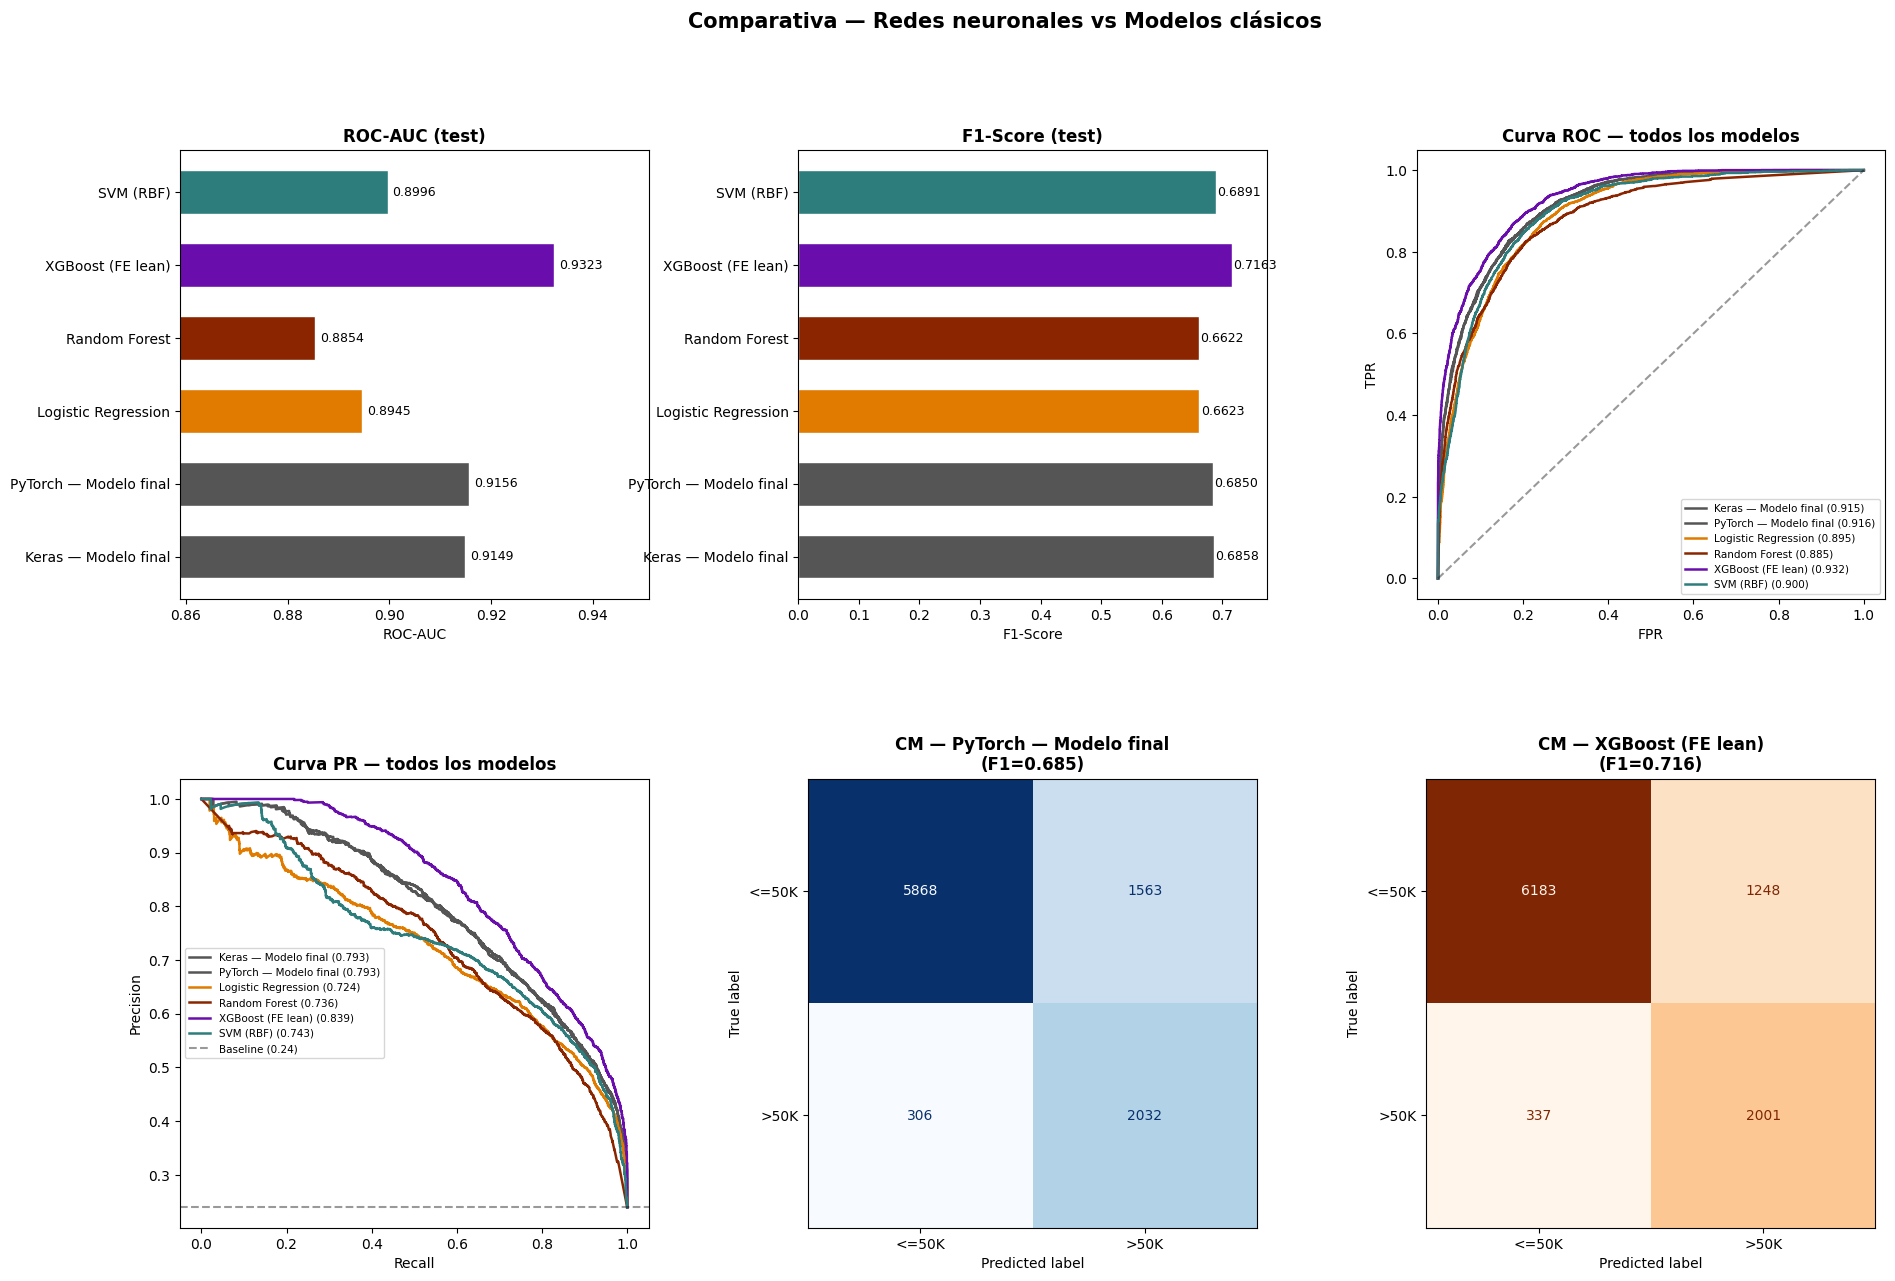

✅ Gráfico comparativa guardado en plots/ablation/comparativa_clasicos_vs_redes.png


In [12]:
todos = list(resultados_redes.values()) + list(resultados_clasicos.values())
nombres_todos = [r['nombre'] for r in todos]

palette = {
    "Keras final":        "#1e6fba",
    "PyTorch final":      "#1b6e44",
    "Logistic Regression":"#e07b00",
    "Random Forest":      "#8b2500",
    "XGBoost (FE lean)":  "#6a0dad",
    "SVM (RBF)":          "#2d7d7d",
}

fig = plt.figure(figsize=(22, 14))
fig.suptitle("Comparativa — Redes neuronales vs Modelos clásicos", fontsize=15, fontweight='bold')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.32)

# — Barras AUC —
ax = fig.add_subplot(gs[0, 0])
aucs = [r['auc'] for r in todos]
colores_all = [palette.get(r['nombre'],'#555') for r in todos]
bars = ax.barh(nombres_todos, aucs, color=colores_all, edgecolor='white', height=0.6)
ax.set_xlabel("ROC-AUC"); ax.set_title("ROC-AUC (test)", fontweight='bold')
ax.set_xlim(min(aucs)*0.97, min(max(aucs)*1.02, 1.0))
for bar, val in zip(bars, aucs):
    ax.text(val+0.001, bar.get_y()+bar.get_height()/2,
            f"{val:.4f}", va='center', fontsize=9)

# — Barras F1 —
ax = fig.add_subplot(gs[0, 1])
f1s = [r['f1'] for r in todos]
bars = ax.barh(nombres_todos, f1s, color=colores_all, edgecolor='white', height=0.6)
ax.set_xlabel("F1-Score"); ax.set_title("F1-Score (test)", fontweight='bold')
ax.set_xlim(0, max(f1s)*1.08)
for bar, val in zip(bars, f1s):
    ax.text(val+0.002, bar.get_y()+bar.get_height()/2,
            f"{val:.4f}", va='center', fontsize=9)

# — Curvas ROC —
ax = fig.add_subplot(gs[0, 2])
for r in todos:
    fpr, tpr, _ = roc_curve(y_test, r['prob'])
    ax.plot(fpr, tpr, label=f"{r['nombre']} ({r['auc']:.3f})",
            color=palette.get(r['nombre'],'#555'), linewidth=1.8)
ax.plot([0,1],[0,1],'k--',alpha=0.4)
ax.set_title("Curva ROC — todos los modelos", fontweight='bold')
ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.legend(fontsize=7.5)

# — Curvas PR —
ax = fig.add_subplot(gs[1, 0])
for r in todos:
    prec, rec, _ = precision_recall_curve(y_test, r['prob'])
    ax.plot(rec, prec, label=f"{r['nombre']} ({r['pr_auc']:.3f})",
            color=palette.get(r['nombre'],'#555'), linewidth=1.8)
ax.axhline(y_test.mean(), color='k', linestyle='--', alpha=0.4,
           label=f'Baseline ({y_test.mean():.2f})')
ax.set_title("Curva PR — todos los modelos", fontweight='bold')
ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.legend(fontsize=7.5)

# — Matrices de confusión (mejor de cada familia) —
mejor_red     = max(resultados_redes.values(), key=lambda r: r['auc'])
mejor_clasico = max(resultados_clasicos.values(), key=lambda r: r['auc'])

ax = fig.add_subplot(gs[1, 1])
ConfusionMatrixDisplay(mejor_red['cm'], display_labels=['<=50K','>50K']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f"CM — {mejor_red['nombre']}\n(F1={mejor_red['f1']:.3f})", fontweight='bold')

ax = fig.add_subplot(gs[1, 2])
ConfusionMatrixDisplay(mejor_clasico['cm'], display_labels=['<=50K','>50K']).plot(
    ax=ax, colorbar=False, cmap='Oranges')
ax.set_title(f"CM — {mejor_clasico['nombre']}\n(F1={mejor_clasico['f1']:.3f})", fontweight='bold')

plt.savefig("plots/ablation/comparativa_clasicos_vs_redes.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico comparativa guardado en plots/ablation/comparativa_clasicos_vs_redes.png")


## 9. Resumen tabular completo

In [13]:
import pandas as pd

# ── Tabla ablation ──────────────────────────────────────────────────────────
rows_ab = []
for modelo, ablacion in [("Keras", ablation_keras),
                          ("PyTorch", ablation_pytorch),
                          ("XGBoost", ablation_xgboost)]:
    pasos_n = ["Sin FE / sin tuning", "Con FE / sin tuning",
               "Con FE / con tuning", "Modelo final"]
    for paso, res in zip(pasos_n, ablacion):
        rows_ab.append({
            "Modelo": modelo, "Paso": paso,
            "ROC-AUC": round(res['auc'],4), "PR-AUC": round(res['pr_auc'],4),
            "F1": round(res['f1'],4), "Accuracy": round(res['acc'],4),
        })
df_ablation = pd.DataFrame(rows_ab)
print("\n" + "═"*65)
print("ABLATION STUDY — ROC-AUC por paso")
print("═"*65)
print(df_ablation.to_string(index=False))

# ── Tabla comparativa ───────────────────────────────────────────────────────
rows_cmp = []
for r in todos:
    rows_cmp.append({
        "Modelo": r['nombre'],
        "Tipo": "Red neuronal" if r['nombre'] in resultados_redes else "Clásico",
        "ROC-AUC": round(r['auc'],4), "PR-AUC": round(r['pr_auc'],4),
        "F1": round(r['f1'],4), "Accuracy": round(r['acc'],4),
    })
df_comparativa = pd.DataFrame(rows_cmp).sort_values("ROC-AUC", ascending=False)
print("\n" + "═"*65)
print("COMPARATIVA — Redes vs Clásicos (ordenado por ROC-AUC)")
print("═"*65)
print(df_comparativa.to_string(index=False))

# ── Guardado ────────────────────────────────────────────────────────────────
df_ablation.to_csv("plots/ablation/tabla_ablation.csv", index=False)
df_comparativa.to_csv("plots/ablation/tabla_comparativa.csv", index=False)

# ── Interpretación automática ───────────────────────────────────────────────
print("\n" + "─"*65)
print("INTERPRETACIÓN DEL ABLATION (Keras como referencia):")
auc_k = [r['auc'] for r in ablation_keras]
print(f"  • Feature Engineering aportó  : +{auc_k[1]-auc_k[0]:+.4f} AUC")
print(f"  • Tuning de hiperparámetros   : +{auc_k[2]-auc_k[1]:+.4f} AUC")
print(f"  • Entrenamiento en train_full : +{auc_k[3]-auc_k[2]:+.4f} AUC")
print(f"  • Ganancia total              : +{auc_k[3]-auc_k[0]:+.4f} AUC")

mejor_total = df_comparativa.iloc[0]
print(f"\nMejor modelo global: {mejor_total['Modelo']} "
      f"(ROC-AUC = {mejor_total['ROC-AUC']:.4f})")
print("═"*65)
print("\n✅ 05_ablation_study.ipynb completado")
print("   · plots/ablation/ablation_waterfall_roc.png")
print("   · plots/ablation/comparativa_clasicos_vs_redes.png")
print("   · plots/ablation/tabla_ablation.csv")
print("   · plots/ablation/tabla_comparativa.csv")



═════════════════════════════════════════════════════════════════
ABLATION STUDY — ROC-AUC por paso
═════════════════════════════════════════════════════════════════
 Modelo                Paso  ROC-AUC  PR-AUC     F1  Accuracy
  Keras Sin FE / sin tuning   0.9123  0.7826 0.6849    0.8161
  Keras Con FE / sin tuning   0.8801  0.6924 0.6380    0.7784
  Keras Con FE / con tuning   0.8851  0.6985 0.6448    0.7770
  Keras        Modelo final   0.9149  0.7933 0.6858    0.8104
PyTorch Sin FE / sin tuning   0.9132  0.7846 0.6805    0.8055
PyTorch Con FE / sin tuning   0.9120  0.7844 0.6811    0.8110
PyTorch Con FE / con tuning   0.9133  0.7868 0.6824    0.8103
PyTorch        Modelo final   0.9156  0.7935 0.6850    0.8087
XGBoost Sin FE / sin tuning   0.9315  0.8355 0.7120    0.8332
XGBoost Con FE / sin tuning   0.9315  0.8361 0.7116    0.8336
XGBoost Con FE / con tuning   0.9322  0.8377 0.7157    0.8368
XGBoost        Modelo final   0.9323  0.8388 0.7163    0.8378

══════════════════════════